# Entrenamiento de modelo TensorFlow para predecir GRD

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

df = pd.read_csv('df_filtrado.csv')


df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce')
df['Sexo'] = pd.to_numeric(df['Sexo'], errors='coerce')


df.fillna('Desconocido', inplace=True)

text_columns = [col for col in df.columns if 'Diag' in col or 'Proced' in col]
df['features_text'] = df[text_columns].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

#Tokenización
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['features_text'])
sequences = tokenizer.texts_to_sequences(df['features_text'])
padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(sequences, padding='post', maxlen=120)

X_extra = df[['Edad', 'Sexo']].values
X = np.hstack((padded_sequences, X_extra))


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['GRD'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Modelo
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=16, input_length=100),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test), batch_size=32)


test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")


Epoch 1/200


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2692 - loss: 2.1448 - val_accuracy: 0.4217 - val_loss: 1.4867
Epoch 2/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5053 - loss: 1.3739 - val_accuracy: 0.6338 - val_loss: 0.9876
Epoch 3/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6532 - loss: 0.9180 - val_accuracy: 0.7164 - val_loss: 0.7307
Epoch 4/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7574 - loss: 0.6835 - val_accuracy: 0.7953 - val_loss: 0.5550
Epoch 5/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8261 - loss: 0.5119 - val_accuracy: 0.8656 - val_loss: 0.4116
Epoch 6/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8642 - loss: 0.3912 - val_accuracy: 0.8977 - val_loss: 0.3349
Epoch 7/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8920 - loss: 0.3243 - val_accuracy: 0.9026 - val_loss: 0.3090
Epoch 8/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9117 - loss: 0.2730 - val_accuracy: 0.9199

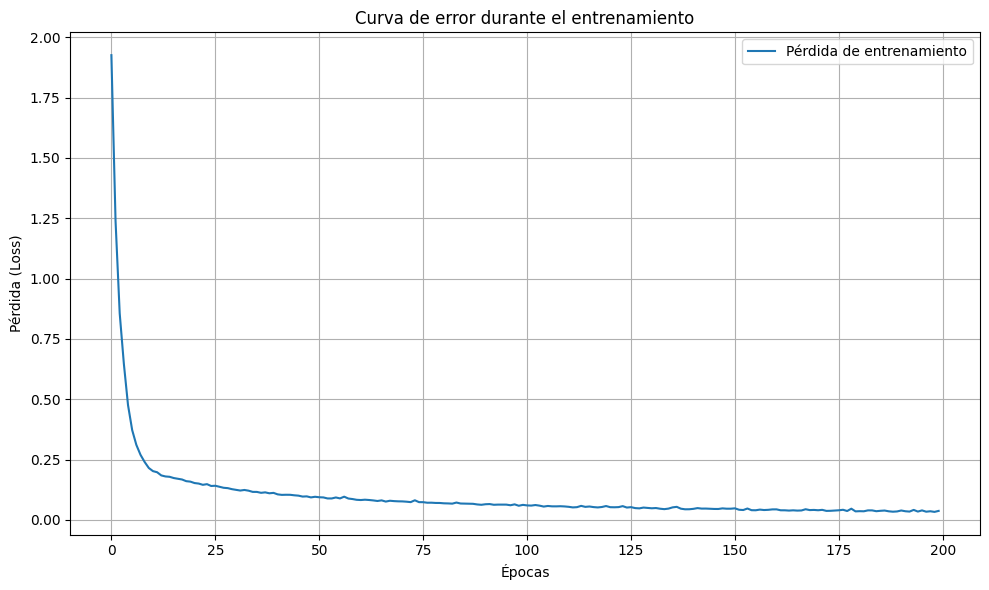

In [ ]:
import matplotlib.pyplot as plt

#Historial de entrenamiento
history_dict = history.history

plt.figure(figsize=(10, 6))
plt.plot(history_dict['loss'], label='Pérdida de entrenamiento')

plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.title('Curva de error durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) 

print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.84      0.95      0.89        40
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.97      0.87      0.92        76
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       0.96      0.98      0.97        47
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.93      0.97      0.95        72
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.97      0.99      0.98        70
                                                                   146101 - PH CESÁREA       0.86      0.86      0.86       162
                                                              14

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step


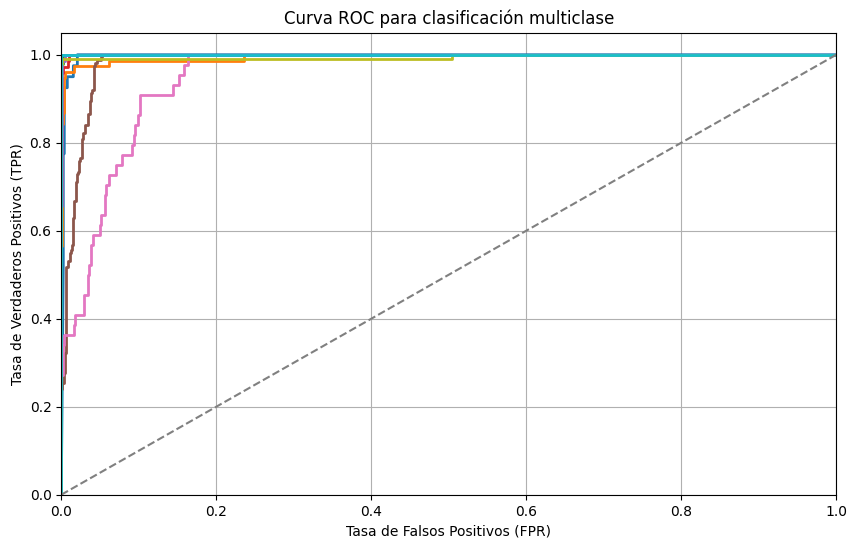

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

#Binarizar las etiquetas verdaderas
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))

y_pred_prob = model.predict(X_test)

plt.figure(figsize=(10, 6))

for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para clasificación multiclase')

plt.grid(True)
plt.show()
